In [41]:
import pandas as pd
from matplotlib.ticker import PercentFormatter
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats
import numpy as np

from scipy.stats import gaussian_kde

In [63]:
file_df = pd.read_csv("../file_level_py_raw.csv")

In [64]:
projects_df = pd.read_csv("../proj_level_py.csv")

In [44]:
file_df.columns

Index(['Unnamed: 0', 'url_x', 'proj_name', 'file_path', 'file_name', 'extn',
       'n_lines', 'blank_lines', 'char', 'source', 'n_functions',
       'n_async_functions', 'class_count', 'n_at_end_of_code_line_block',
       'n_at_end_of_code_line_line', 'n_blank_in_docstring_block',
       'n_blank_in_docstring_line', 'n_comment_lines_block',
       'n_comment_lines_line', 'n_comments_block', 'n_comments_line',
       'n_imports', 'n_fn_imports', 'n_class_imports', 'url', 'n_calls',
       'n_unique_fn_calls', 'n_unique_class_calls', 'n_comments_lines',
       'n_comments', 'avg_lines_in_comment', 'n_code_lines', 'blank_by_code',
       'percent_comments', 'char_by_code', 'n_functions_by_code',
       'n_async_functions_by_code', 'class_count_by_code',
       'n_comment_lines_block_by_code', 'n_comment_lines_line_by_code',
       'n_imports_by_code', 'n_calls_by_code', 'n_comments_block_by_code',
       'n_comments_line_by_code', 'avg_len_block_comment',
       'avg_len_line_comment', 

In [45]:
projects_df.columns

Index(['Unnamed: 0', 'url', 'source', 'n_files', 'n_lines', 'n_chars',
       'n_blank_lines', 'n_imports', 'n_unique_imports', 'n_functions',
       'n_async_functions', 'class_count', 'n_at_end_of_code_line_block',
       'n_at_end_of_code_line_line', 'n_blank_in_docstring_block',
       'n_blank_in_docstring_line', 'n_comment_lines_block',
       'n_comment_lines_line', 'n_comments_block', 'n_comments_line',
       'n_fn_imports', 'n_fn_called', 'convention', 'error', 'info',
       'refactor', 'warning', 'n_duplications', 'n_lines_py',
       'n_comments_lines', 'n_comments', 'avg_lines_in_comment',
       'percent_comment_lines', 'unique_imports_per_project',
       'imports_per_code_line', 'avg_file_length', 'percent_blank_lines',
       'percent_code_lines'],
      dtype='str')

In [46]:
file_df.n_functions_by_code

0             NaN
1             NaN
2        0.000000
3        0.000000
4        0.058824
           ...   
17774    0.000000
17775    0.068966
17776    0.270270
17777    0.029197
17778    0.043478
Name: n_functions_by_code, Length: 17779, dtype: float64

In [47]:
projects_df.n_functions

0      0.072034
1      0.063107
2      0.027088
3      0.068750
4      0.045961
         ...   
317    0.047685
318    0.057172
319         NaN
320    0.142857
321    0.032898
Name: n_functions, Length: 322, dtype: float64

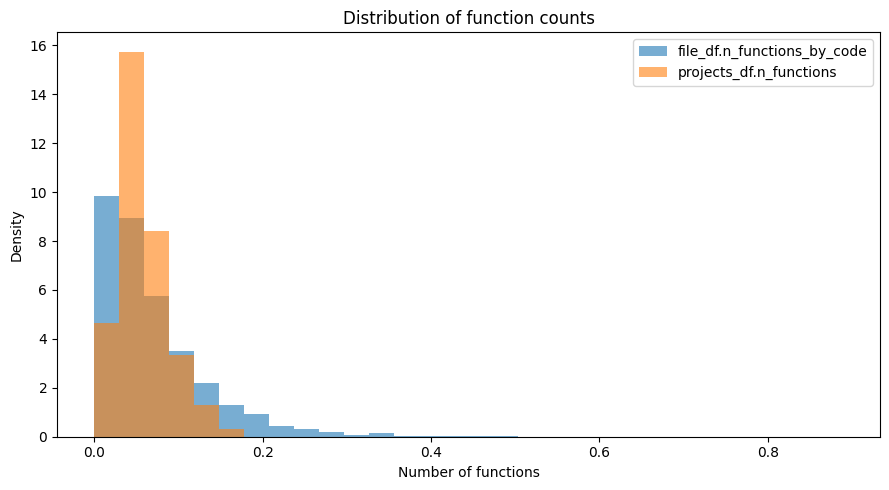

In [48]:

a = file_df["n_functions_by_code"].dropna()
b = projects_df["n_functions"].dropna()

# Shared bin edges so the bars line up
bins = np.histogram_bin_edges(np.concatenate([a, b]), bins=30)

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(a, bins=bins, alpha=0.6, label="file_df.n_functions_by_code", density=True)
ax.hist(b, bins=bins, alpha=0.6, label="projects_df.n_functions", density=True)

ax.set_xlabel("Number of functions")
ax.set_ylabel("Density")
ax.set_title("Distribution of function counts")
ax.legend()
plt.tight_layout()
plt.show()

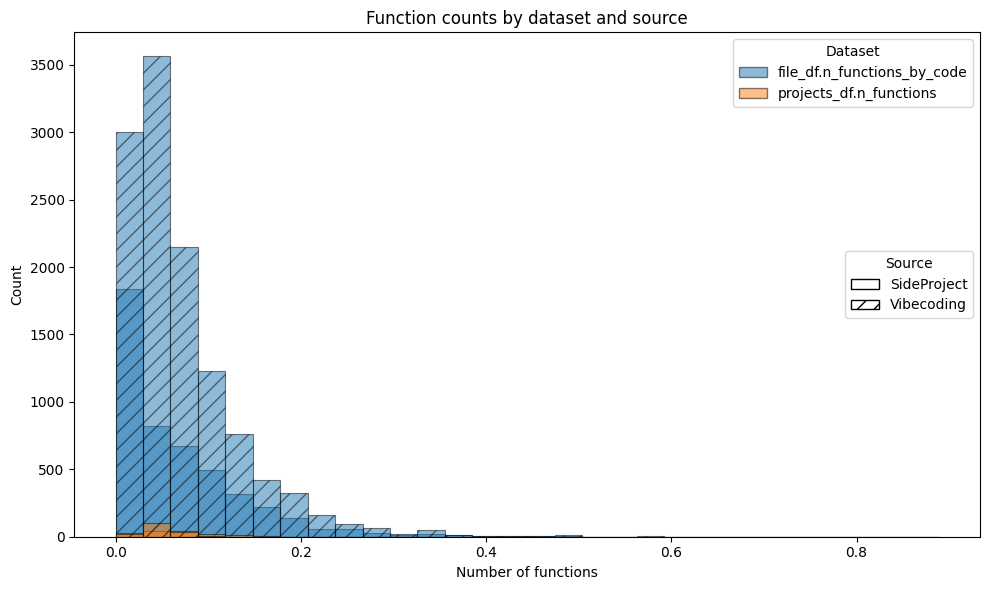

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

a_col = "n_functions_by_code"
b_col = "n_functions"

# Shared bin edges across everything
all_vals = np.concatenate([file_df[a_col].dropna(), projects_df[b_col].dropna()])
bins = np.histogram_bin_edges(all_vals, bins=30)

# One hatch per unique source (consistent across both dataframes)
sources = sorted(set(file_df["source"].dropna()) | set(projects_df["source"].dropna()))
hatch_styles = ["", "//", "\\\\", "xx", "..", "oo", "++", "--"]
hatches = {s: hatch_styles[i % len(hatch_styles)] for i, s in enumerate(sources)}

datasets = [
    (file_df, a_col, "file_df.n_functions_by_code", "tab:blue"),
    (projects_df, b_col, "projects_df.n_functions", "tab:orange"),
]

fig, ax = plt.subplots(figsize=(10, 6))

for df, col, label, color in datasets:
    for s in sources:
        vals = df.loc[df["source"] == s, col].dropna()
        if vals.empty:
            continue
        ax.hist(
            vals, bins=bins, alpha=0.5, density=False,
            facecolor=color, edgecolor="black", hatch=hatches[s], linewidth=0.8,
        )

# Build a legend manually: colors = dataset, hatches = source
color_handles = [Patch(facecolor=c, alpha=0.5, edgecolor="black", label=l)
                 for _, _, l, c in datasets]
hatch_handles = [Patch(facecolor="white", edgecolor="black", hatch=hatches[s], label=str(s))
                 for s in sources]

leg1 = ax.legend(handles=color_handles, title="Dataset", loc="upper right")
ax.add_artist(leg1)
ax.legend(handles=hatch_handles, title="Source", loc="center right")

ax.set_xlabel("Number of functions")
ax.set_ylabel("Count")
ax.set_title("Function counts by dataset and source")
plt.tight_layout()
plt.show()

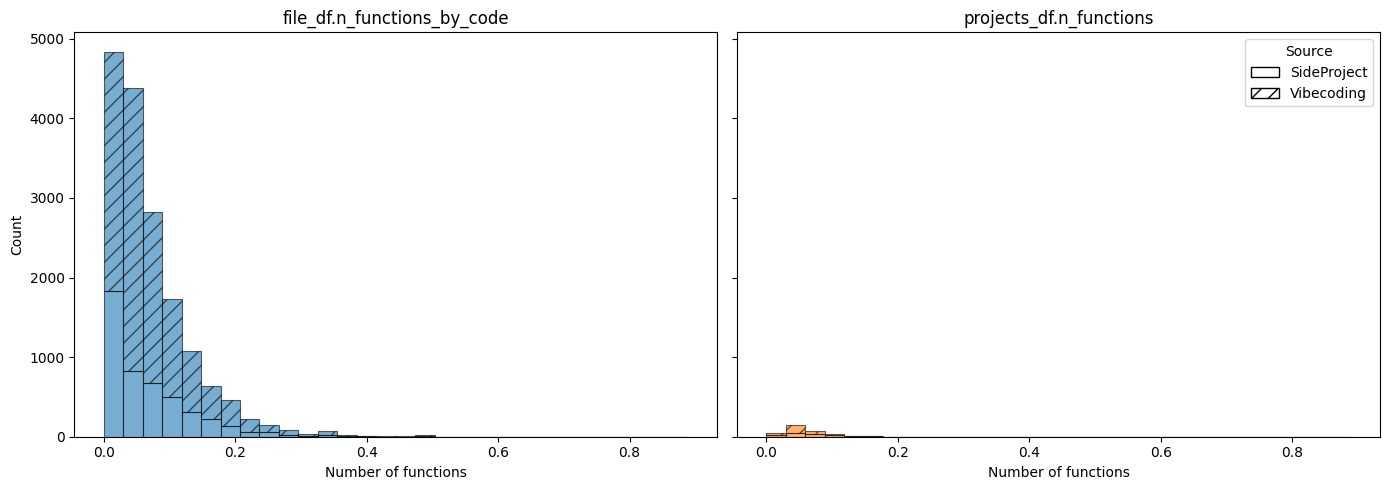

In [50]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for ax, (df, col, label, color) in zip(axes, datasets):
    data = [df.loc[df["source"] == s, col].dropna() for s in sources]
    n, _, patches = ax.hist(
        data, bins=bins, stacked=True, alpha=0.6,
        color=[color] * len(sources), edgecolor="black", linewidth=0.8,
    )
    for patch_group, s in zip(patches, sources):
        for p in patch_group:
            p.set_hatch(hatches[s])
    ax.set_title(label)
    ax.set_xlabel("Number of functions")

axes[0].set_ylabel("Count")
hatch_handles = [Patch(facecolor="white", edgecolor="black", hatch=hatches[s], label=str(s))
                 for s in sources]
axes[1].legend(handles=hatch_handles, title="Source")
plt.tight_layout()
plt.show()

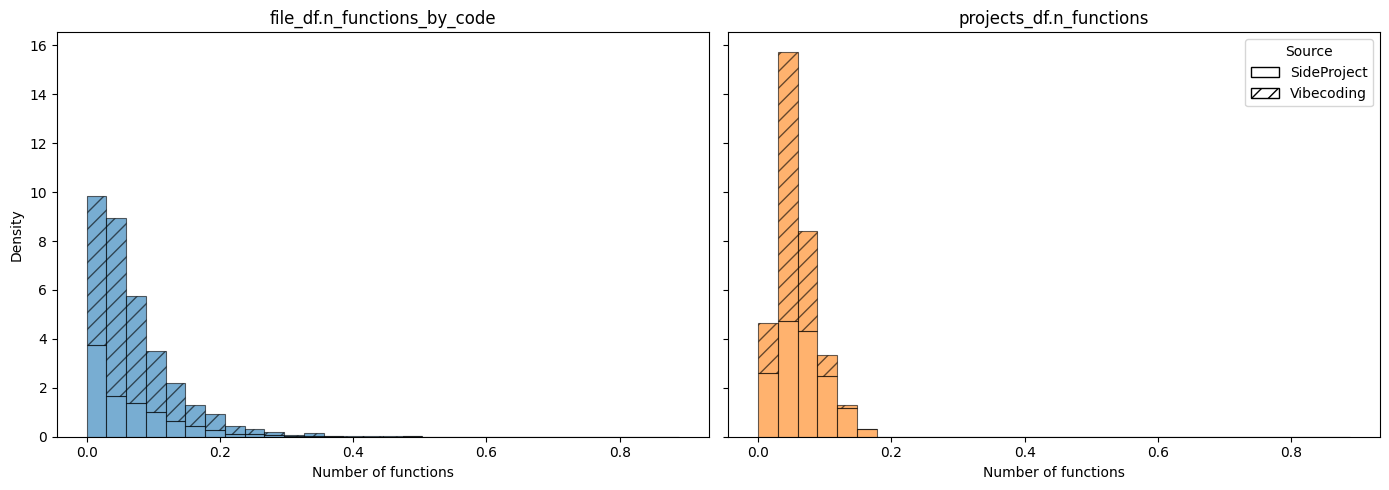

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

a_col = "n_functions_by_code"
b_col = "n_functions"

# Shared bin edges across everything
all_vals = np.concatenate([file_df[a_col].dropna(), projects_df[b_col].dropna()])
bins = np.histogram_bin_edges(all_vals, bins=30)
widths = np.diff(bins)
centers = bins[:-1] + widths / 2

# One hatch per unique source, consistent across both dataframes
sources = sorted(set(file_df["source"].dropna()) | set(projects_df["source"].dropna()))
hatch_styles = ["", "//", "\\\\", "xx", "..", "oo", "++", "--"]
hatches = {s: hatch_styles[i % len(hatch_styles)] for i, s in enumerate(sources)}

datasets = [
    (file_df, a_col, "file_df.n_functions_by_code", "tab:blue"),
    (projects_df, b_col, "projects_df.n_functions", "tab:orange"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for ax, (df, col, label, color) in zip(axes, datasets):
    total = df[col].dropna().shape[0]          # normalize by the whole dataset
    bottom = np.zeros(len(centers))

    for s in sources:
        vals = df.loc[df["source"] == s, col].dropna()
        counts, _ = np.histogram(vals, bins=bins)
        density = counts / (total * widths)     # this source's contribution to density
        ax.bar(
            centers, density, width=widths, bottom=bottom,
            facecolor=color, alpha=0.6, edgecolor="black", linewidth=0.8,
            hatch=hatches[s],
        )
        bottom += density

    ax.set_title(label)
    ax.set_xlabel("Number of functions")

axes[0].set_ylabel("Density")

hatch_handles = [Patch(facecolor="white", edgecolor="black", hatch=hatches[s], label=str(s))
                 for s in sources]
axes[1].legend(handles=hatch_handles, title="Source")

plt.tight_layout()
plt.show()

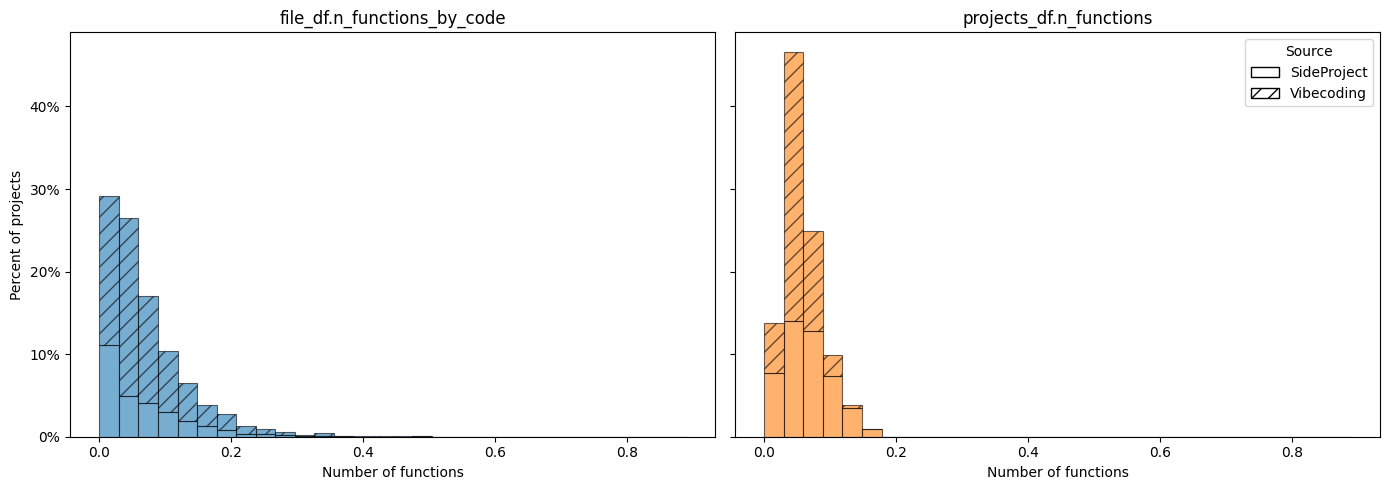

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.ticker import PercentFormatter

a_col = "n_functions_by_code"
b_col = "n_functions"

# Shared bin edges across everything
all_vals = np.concatenate([file_df[a_col].dropna(), projects_df[b_col].dropna()])
bins = np.histogram_bin_edges(all_vals, bins=30)
widths = np.diff(bins)
centers = bins[:-1] + widths / 2

# One hatch per unique source, consistent across both dataframes
sources = sorted(set(file_df["source"].dropna()) | set(projects_df["source"].dropna()))
hatch_styles = ["", "//", "\\\\", "xx", "..", "oo", "++", "--"]
hatches = {s: hatch_styles[i % len(hatch_styles)] for i, s in enumerate(sources)}

datasets = [
    (file_df, a_col, "file_df.n_functions_by_code", "tab:blue"),
    (projects_df, b_col, "projects_df.n_functions", "tab:orange"),
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)

for ax, (df, col, label, color) in zip(axes, datasets):
    total = df[col].dropna().shape[0]           # denominator: all projects in this dataset
    bottom = np.zeros(len(centers))

    for s in sources:
        vals = df.loc[df["source"] == s, col].dropna()
        counts, _ = np.histogram(vals, bins=bins)
        pct = counts / total * 100              # percent of ALL projects in this dataset
        ax.bar(
            centers, pct, width=widths, bottom=bottom,
            facecolor=color, alpha=0.6, edgecolor="black", linewidth=0.8,
            hatch=hatches[s],
        )
        bottom += pct

    ax.set_title(label)
    ax.set_xlabel("Number of functions")

axes[0].set_ylabel("Percent of projects")
axes[0].yaxis.set_major_formatter(PercentFormatter(decimals=0))

hatch_handles = [Patch(facecolor="white", edgecolor="black", hatch=hatches[s], label=str(s))
                 for s in sources]
axes[1].legend(handles=hatch_handles, title="Source")

plt.tight_layout()
plt.show()

In [67]:
# 1. Compare sample sizes and project sizes
print(file_df.groupby("source").size())
print(projects_df.groupby("source").size())
print(file_df.groupby(["source", 'url']).size().groupby("source").describe())  # files per project

# 2. Recompute the project-level ratio from file-level data, both ways
per_proj = file_df.groupby(["source", 'url']).agg(
    total_funcs=("n_functions", "sum"),
    total_code=('n_lines', "sum"),
    mean_file_ratio=("n_functions_by_code", "mean"),   # unweighted
)
per_proj["weighted_ratio"] = per_proj.total_funcs / per_proj.total_code
print(per_proj.groupby("source")[["mean_file_ratio", "weighted_ratio"]].median())

# 3. Does file size correlate with density, and does that differ by source?
print(file_df.groupby("source")[['n_lines', "n_functions_by_code"]].corr(method="spearman"))

source
SideProject     5061
Vibecoding     12718
dtype: int64
source
SideProject    152
Vibecoding     170
dtype: int64
             count       mean         std  min  25%   50%   75%     max
source                                                                 
SideProject  152.0  33.296053  107.366787  1.0  3.0   7.0  22.5   976.0
Vibecoding   170.0  74.811765  253.097801  1.0  3.0  18.0  49.0  2725.0
             mean_file_ratio  weighted_ratio
source                                      
SideProject         0.064846        0.039197
Vibecoding          0.053565        0.031250
                                  n_lines  n_functions_by_code
source                                                        
SideProject n_lines              1.000000             0.116296
            n_functions_by_code  0.116296             1.000000
Vibecoding  n_lines              1.000000             0.082553
            n_functions_by_code  0.082553             1.000000


In [65]:
print(file_df.groupby("source")["url"].nunique())
print(set(file_df.url) - set(projects_df.url))   # in files, missing from projects
print(set(projects_df.url) - set(file_df.url))   # in projects, missing from files

source
SideProject    152
Vibecoding     170
Name: url, dtype: int64
set()
set()


In [66]:
# Drop NAs in the columns used for the plots and for matching
files_clean = file_df.dropna(subset=["url", "source", "n_functions_by_code"])
projects_clean = projects_df.dropna(subset=["url", "source", "n_functions"])

print("Unique urls per source (files):")
print(files_clean.groupby("source")["url"].nunique())

print("\nUnique urls per source (projects):")
print(projects_clean.groupby("source")["url"].nunique())

# In files but missing from projects
missing_in_projects = set(files_clean["url"]) - set(projects_clean["url"])
print(f"\nurls in file_df but not in projects_df: {len(missing_in_projects)}")
print(list(missing_in_projects)[:10])

# The reverse direction (in projects but no usable files)
missing_in_files = set(projects_clean["url"]) - set(files_clean["url"])
print(f"\nurls in projects_df but not in file_df: {len(missing_in_files)}")
print(list(missing_in_files)[:10])

Unique urls per source (files):
source
SideProject    152
Vibecoding     170
Name: url, dtype: int64

Unique urls per source (projects):
source
SideProject    145
Vibecoding     168
Name: url, dtype: int64

urls in file_df but not in projects_df: 9
['https://github.com/zackumar/newspaper_snippets', 'https://github.com/calganaygun/MDcat', 'https://github.com/Gupta-Aniket/file-context', 'https://github.com/SigNoz/signoz', 'https://github.com/carlortiz/Lakers-Turnovers-Tracker', 'https://github.com/mjamry/youtubeScrobbler', 'https://github.com/arrold/vibechck', 'https://github.com/polarsteps-tracker/polarsteps-slack-bot', 'https://github.com/jdc-cunningham/3-positives']

urls in projects_df but not in file_df: 0
[]


In [56]:
def make_mask(df_source, df_files, name):  
    mask = (df_source[name])
    name_df = df_source[mask]
    url_set = set(name_df["url"])
    mask = (df_files["url"].isin(url_set))
    masked_files = df_files[mask] 
    return masked_files

In [57]:
df = pd.read_csv("../../dataset_features/files_raw.csv", names=["url", "proj_name", "file_path", "file_name", "extn", "n_lines", "blank_lines", "char"])
df.drop_duplicates(subset=["file_path"], inplace=True)
source= pd.read_csv( "../../main_exp_sheet.csv",  index_col=0)
source.drop_duplicates(inplace=True)
names = ["Vibecoding", "SideProject"]

py_vc = make_mask(source, df, names[0])
py_sp = make_mask(source, df, names[1])

py_sp["source"] = "SideProject"
py_vc["source"] = "Vibecoding"

df_all = pd.concat([py_sp, py_vc], ignore_index=True)

#cleaning files to remove the .git folder

df_all_all = df_all[~df_all["file_path"].str.contains("/.git/")]

#adding in the files that couldn't be read
df_failed = pd.read_csv("../../dataset_features/clone_failures.csv", names=["url", "proj_name", "file_path", "reason"])
df_failed = df_failed.drop_duplicates(subset=["file_path"], keep="last")
# df_failed.drop_duplicates(inplace=True)
# print(df_failed.head())


py_vc = make_mask(source, df_failed, names[0])
py_sp = make_mask(source, df_failed, names[1])

py_sp["source"] = "SideProject"
py_vc["source"] = "Vibecoding"
df_failed_all = pd.concat([py_sp, py_vc], ignore_index=True)
df_failed_all = df_failed_all[~df_failed_all["file_path"].str.contains("/.git/")]

df_merged_all = pd.concat([df_failed_all, df_all_all], join='outer', axis=0, ignore_index=True)
# print(df_merged_all.size) 
# df_merged_all.drop("reason")
df_merged_all = df_merged_all[df_merged_all["extn"] == "py"]
df_all_py = df_merged_all.groupby(["url", "source"]).agg(
    n_files = ("url", "size"),
    n_lines =("n_lines", "sum"),
    n_chars = ("char", "sum"),
    n_blank_lines = ("blank_lines", "sum")
).reset_index()
print(df_all_py.head())

                                                url       source  n_files  \
0          https://github.com/2018kguo/RobinhoodBot  SideProject        3   
1  https://github.com/AI-Spawn/multiplayer-game-bot  SideProject        1   
2              https://github.com/AI-Spawn/ssbm-bot  SideProject       10   
3            https://github.com/Adam-Jimenez/auddit  SideProject       12   
4         https://github.com/AdarshB7/patcha-engine   Vibecoding       25   

   n_lines   n_chars  n_blank_lines  
0    391.0   13795.0           45.0  
1    274.0    5530.0           67.0  
2   1220.0   30208.0          242.0  
3    392.0    9958.0           60.0  
4   4041.0  119624.0          531.0  


In [58]:
df_all_py.groupby("source")["url"].nunique()

source
SideProject    152
Vibecoding     170
Name: url, dtype: int64

In [76]:
import numpy as np
import pandas as pd
from scipy import stats

# --- 0. Setup: file counts and total density per project ---
proj_files = file_df.groupby(["source", "url"]).agg(
    n_files=("n_functions_by_code", "size"),
    mean_file_density=("n_functions_by_code", "mean"),
).reset_index()

proj_files = proj_files.merge(
    projects_df[["url", "n_functions"]], on="url", how="left"
)

for s, g in proj_files.groupby("source"):
    g = g.sort_values("n_files", ascending=False)
    top5_share = g["n_files"].head(5).sum() / g["n_files"].sum() * 100
    print(f"{s}: top 5 projects = {top5_share:.1f}% of all files, "
          f"n_projects={len(g)}, max_files={g['n_files'].max()}")

print()

def file_level_test(df):
    v = df.loc[df.source == "Vibecoding", "n_functions_by_code"].dropna()
    s = df.loc[df.source == "SideProject", "n_functions_by_code"].dropna()
    u, p = stats.mannwhitneyu(v, s, alternative="two-sided")
    return v.median(), s.median(), p

print("Full data:", file_level_test(file_df))

# Exclude files from the largest 5% of projects, per source
cutoff = proj_files.groupby("source")["n_files"].transform(lambda x: x.quantile(0.95))
big_projects = proj_files.loc[proj_files["n_files"] > cutoff, ["source", "url"]]

trimmed = file_df.merge(big_projects, on=["source", "url"], how="left", indicator=True)
trimmed = trimmed[trimmed["_merge"] == "left_only"]
print("Trimmed (excl. top 5% largest projects):", file_level_test(trimmed))

file_df["w"] = 1 / file_df.groupby(["source", "url"])["n_functions_by_code"].transform("size")

print()

def weighted_median(df, col, wcol):
    d = df.dropna(subset=[col, wcol]).sort_values(col)
    cum = d[wcol].cumsum()
    cutoff = d[wcol].sum() / 2
    return d.loc[cum >= cutoff, col].iloc[0]

for s, g in file_df.groupby("source"):
    print(s, "project-weighted median:", weighted_median(g, "n_functions_by_code", "w"))

print()
for s, g in proj_files.groupby("source"):
    rho, p = stats.spearmanr(g["n_files"], g["mean_file_density"])
    print(f"{s}: corr(n_files, mean_file_density) = {rho:.3f}, p={p:.4f}")

print()
top_vibe = proj_files[proj_files.source == "Vibecoding"].sort_values("n_files", ascending=False).head(10)
print(top_vibe[["url", "n_files", "mean_file_density", "n_functions"]])

SideProject: top 5 projects = 47.9% of all files, n_projects=152, max_files=976
Vibecoding: top 5 projects = 48.8% of all files, n_projects=170, max_files=2725

Full data: (np.float64(0.0530362123575852), np.float64(0.0471698113207547), np.float64(1.3238651512688911e-12))
Trimmed (excl. top 5% largest projects): (np.float64(0.0468085106382978), np.float64(0.058252427184466), np.float64(0.07252079791711033))

SideProject project-weighted median: 0.0573248407643312
Vibecoding project-weighted median: 0.0439471555675384

SideProject: corr(n_files, mean_file_density) = 0.227, p=0.0048
Vibecoding: corr(n_files, mean_file_density) = 0.374, p=0.0000

                                                 url  n_files  \
269    https://github.com/kimeisele/steward-protocol     2725   
229          https://github.com/bookcard-io/bookcard     1259   
255             https://github.com/hshadab/kinic-api      827   
248         https://github.com/fabriziosalmi/wildbox      735   
200        https://gith